# 00. Anàlisi Exploratòria de Dades (EDA)

## 0. Càrrega de Llibreries i Configuració Global
En aquesta primera secció s'importen totes les llibreries necessàries per al processament de dades i la generació de gràfics, i es defineixen els directoris d'exportació globals per a l'anàlisi exploratòria.

In [15]:
# Llibreries estàndard de processament i sistema
import os
import glob
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np

# Llibreries de visualització
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

# Configuració del directori global d'exportació per a l'EDA
carpeta_eda = "resultats_grafics/analisi_exploratori"
os.makedirs(carpeta_eda, exist_ok=True)

print(f"Llibreries carregades. Directori d'exportació configurat a: '{carpeta_eda}'")

Llibreries carregades. Directori d'exportació configurat a: 'resultats_grafics/analisi_exploratori'


## 1. Anàlisi de Pèrdua de Senyal (Train vs. Test)

Per avaluar la qualitat global del conjunt de dades, és fonamental quantificar la proporció de mostres perdudes respecte al nombre teòric d'enregistraments esperats (una mostra cada 5 minuts per al monitoratge continu). A continuació, es calcula i es visualitza el percentatge de pèrdua de senyal per a cada pacient, desglossat per les particions d'entrenament (*Train*) i prova (*Test*).

Iniciant el càlcul de pèrdua de senyal (Train vs Test)...


Partició,Test,Train
Pacient,,
559,12.60,10.64
563,4.51,7.43
570,4.67,5.42
575,4.74,9.44
588,3.11,3.55
591,3.06,14.96


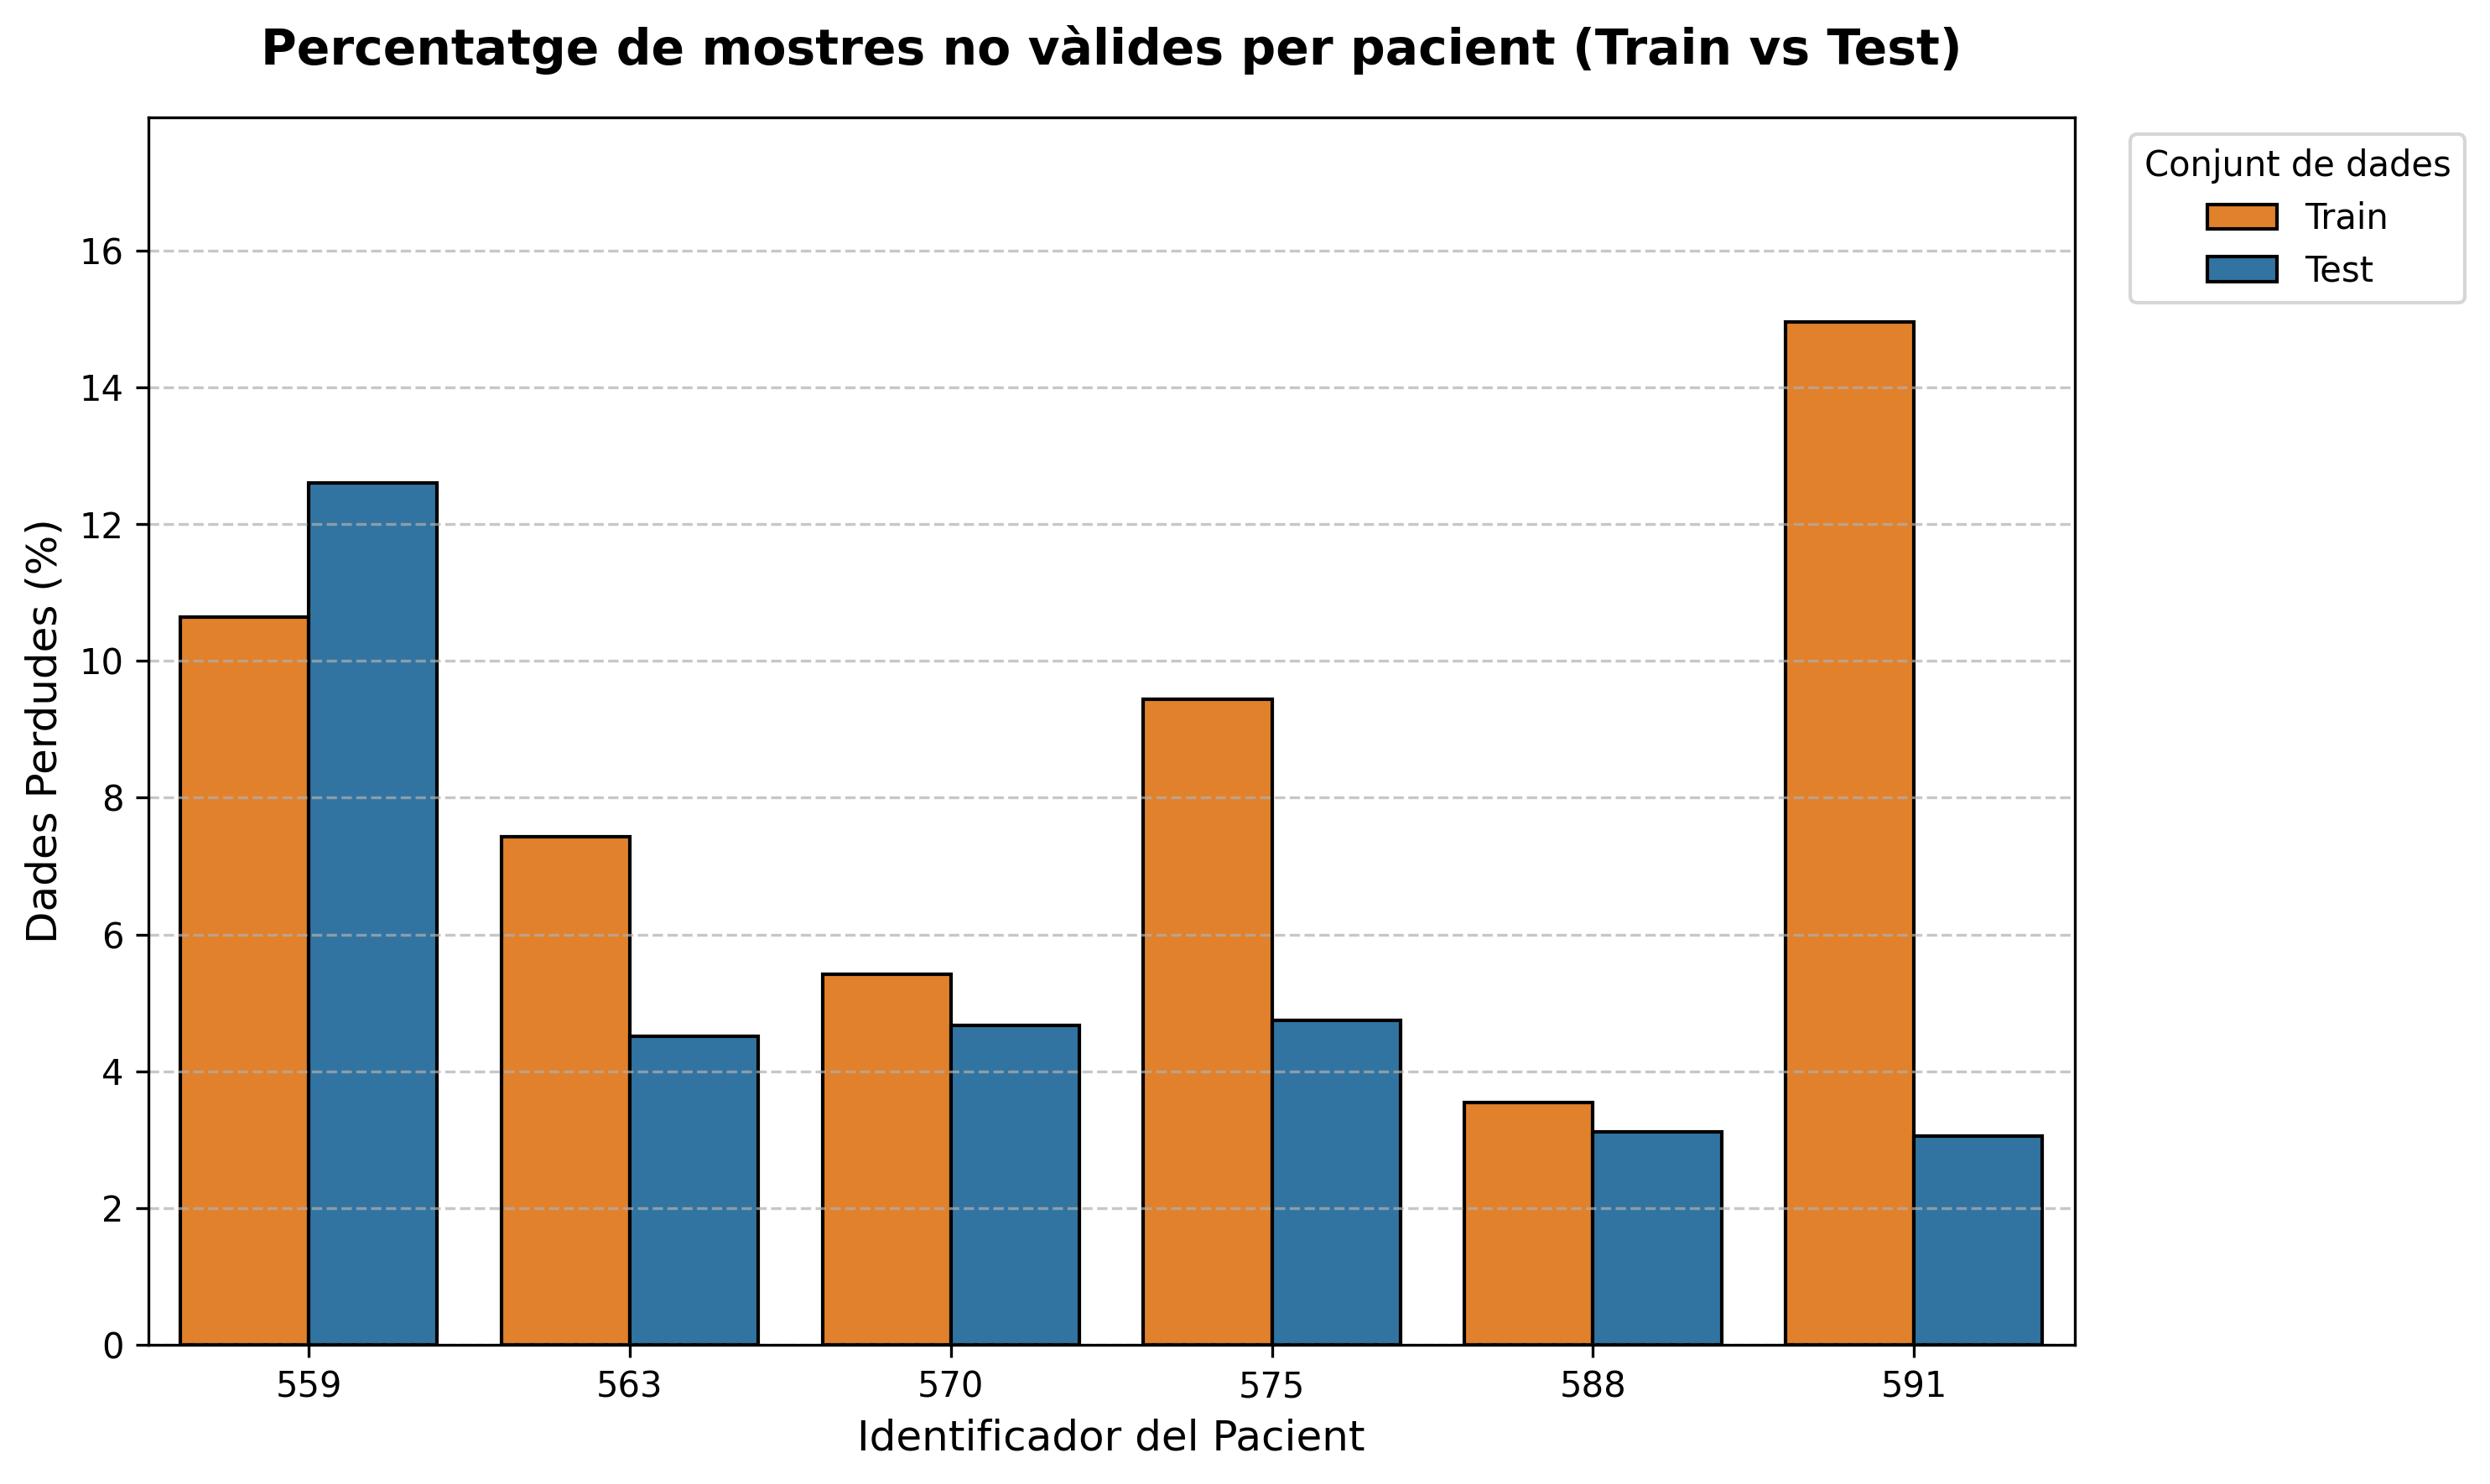

In [18]:
print("Iniciant el càlcul de pèrdua de senyal (Train vs Test)...")

def calcular_percentatge_perdua(ruta_arxiu):
    try:
        tree = ET.parse(ruta_arxiu)
        root = tree.getroot()
        glucose_section = root.find('glucose_level')
        if glucose_section is None: return None

        # Extraic les dades del fitxer XML
        data = [{"timestamp": ev.get("ts"), "glucose": ev.get("value")} for ev in glucose_section.findall('event')]
        df = pd.DataFrame(data)
        df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)
        df = df.set_index('timestamp').sort_index()
        
        # Elimine els duplicats exactes
        df = df[~df.index.duplicated(keep='first')]
        
        # Calcule la pèrdua respecte a les mostres teòriques (1 cada 5 minuts)
        temps_total_minuts = (df.index.max() - df.index.min()).total_seconds() / 60
        mostres_teoriques = (temps_total_minuts / 5) + 1 
        mostres_reals = len(df)
        
        percentatge = max(0, (1 - (mostres_reals / mostres_teoriques)) * 100)
        return round(percentatge, 2)
    except Exception as e:
        return None

resultats_perdua = []
for ruta in glob.glob("archive/*.xml"):
    nom_arxiu = os.path.basename(ruta)
    pacient_id = nom_arxiu.split('-')[0]
    
    particio = "Train" if "training" in nom_arxiu else "Test" if "testing" in nom_arxiu else None
    if not particio: continue
        
    percentatge = calcular_percentatge_perdua(ruta)
    if percentatge is not None:
        resultats_perdua.append({'Pacient': pacient_id, 'Partició': particio, 'Dades Perdudes (%)': percentatge})

# Taula
df_resultats = pd.DataFrame(resultats_perdua)
df_pivot = df_resultats.pivot(index='Pacient', columns='Partició', values='Dades Perdudes (%)')
display(df_pivot)

# Gràfica
plt.figure(figsize=(10, 6), dpi=300)
sns.barplot(
    data=df_resultats, x='Pacient', y='Dades Perdudes (%)', hue='Partició',
    hue_order=['Train', 'Test'], palette={'Train': '#ff7f0e', 'Test': '#1f77b4'}, edgecolor='black'
)
plt.title('Percentatge de mostres no vàlides per pacient (Train vs Test)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Identificador del Pacient', fontsize=12)
plt.ylabel('Dades Perdudes (%)', fontsize=12)
plt.ylim(0, max(df_resultats['Dades Perdudes (%)']) * 1.2) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Conjunt de dades', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
ruta_guardat = os.path.join(carpeta_eda, "dades_perdudes_pacients.png")
plt.savefig(ruta_guardat, format='png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Avaluació de la Continuïtat i Llindars de Segmentació

Una vegada quantificada la pèrdua de senyal, és necessari analitzar com afecta aquesta manca de dades a la continuïtat de la sèrie temporal. S'avalua la disponibilitat de segments contigus en el conjunt de prova en funció de diferents llindars de durada mínima (des d'1 hora fins a 24 hores), establint així el criteri òptim per a l'avaluació dels models.

In [20]:
print("Analitzant la continuïtat dels segments de test...")

llindars = {'1h': 12, '2h': 24, '4h': 48, '6h': 72, '12h': 144, '24h': 288}
resultats_segments = []

for ruta in glob.glob("archive/*-ws-testing.xml"):
    pacient_id = os.path.basename(ruta).split('-')[0]
    
    # Processament ràpid XML
    root = ET.parse(ruta).getroot()
    data = [{"timestamp": ev.get("ts"), "glucose": float(ev.get("value"))} for ev in root.find('glucose_level').findall('event')]
    df = pd.DataFrame(data)
    df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)
    df = df.sort_values('timestamp').reset_index(drop=True)

    # Imputació lineal curta (15 min) i detecció de segments
    df_r = df.set_index('timestamp')['glucose'].resample('5min').mean().interpolate(method='linear', limit=3)
    mask_nans = df_r.isna()
    segment_id = (mask_nans != mask_nans.shift()).cumsum()[~mask_nans]
    df_r = df_r[~mask_nans].copy()

    for llindar_nom, llindar_mostres in llindars.items():
        segments = [(sid, grp) for sid, grp in df_r.groupby(segment_id) if len(grp) >= llindar_mostres]
        resultats_segments.append({
            'Pacient': pacient_id, 'Llindar': llindar_nom,
            'Num_Segments': len(segments), 'Mostres_Totals': sum(len(g) for _, g in segments)
        })

df_res = pd.DataFrame(resultats_segments)
pivot_segments = df_res.pivot_table(index='Pacient', columns='Llindar', values=['Num_Segments', 'Mostres_Totals'], aggfunc='first')
pivot_segments = pivot_segments.reindex(columns=pd.MultiIndex.from_product([['Num_Segments','Mostres_Totals'], ['1h','2h','4h','6h','12h','24h']]))

display(pivot_segments)

ruta_taula = os.path.join(carpeta_eda, "disponibilitat_segments_test.csv")
pivot_segments.to_csv(ruta_taula)

Analitzant la continuïtat dels segments de test...


Num_Segments                     Mostres_Totals                    \
                  1h  2h  4h  6h 12h 24h             1h    2h    4h    6h   
Pacient                                                                     
559               10  10  10  10   9   2           2546  2546  2546  2546   
563                2   2   2   2   2   2           2577  2577  2577  2577   
570                8   8   8   8   7   4           2772  2772  2772  2772   
575                9   8   8   8   7   4           2619  2602  2602  2602   
588                3   3   3   3   3   3           2797  2797  2797  2797   
591                3   3   3   3   3   3           2771  2771  2771  2771   

                     
          12h   24h  
Pacient              
559      2447   883  
563      2577  2577  
570      2700  1973  
575      2529  2035  
588      2797  2797  
591      2771  2771

## 3. Visualització de Discontinuïtats en el Senyal CGM

Per il·lustrar la naturalesa de les interrupcions quantificades anteriorment, es visualitza una finestra temporal de 48 hores d'un pacient real. Aquesta representació permet contrastar el comportament del senyal i identificar gràficament els intervals d'absència de dades (indicats per desconnexions del sensor).

Generant la gràfica d'exemple MCG amb buits reals (48 hores)...


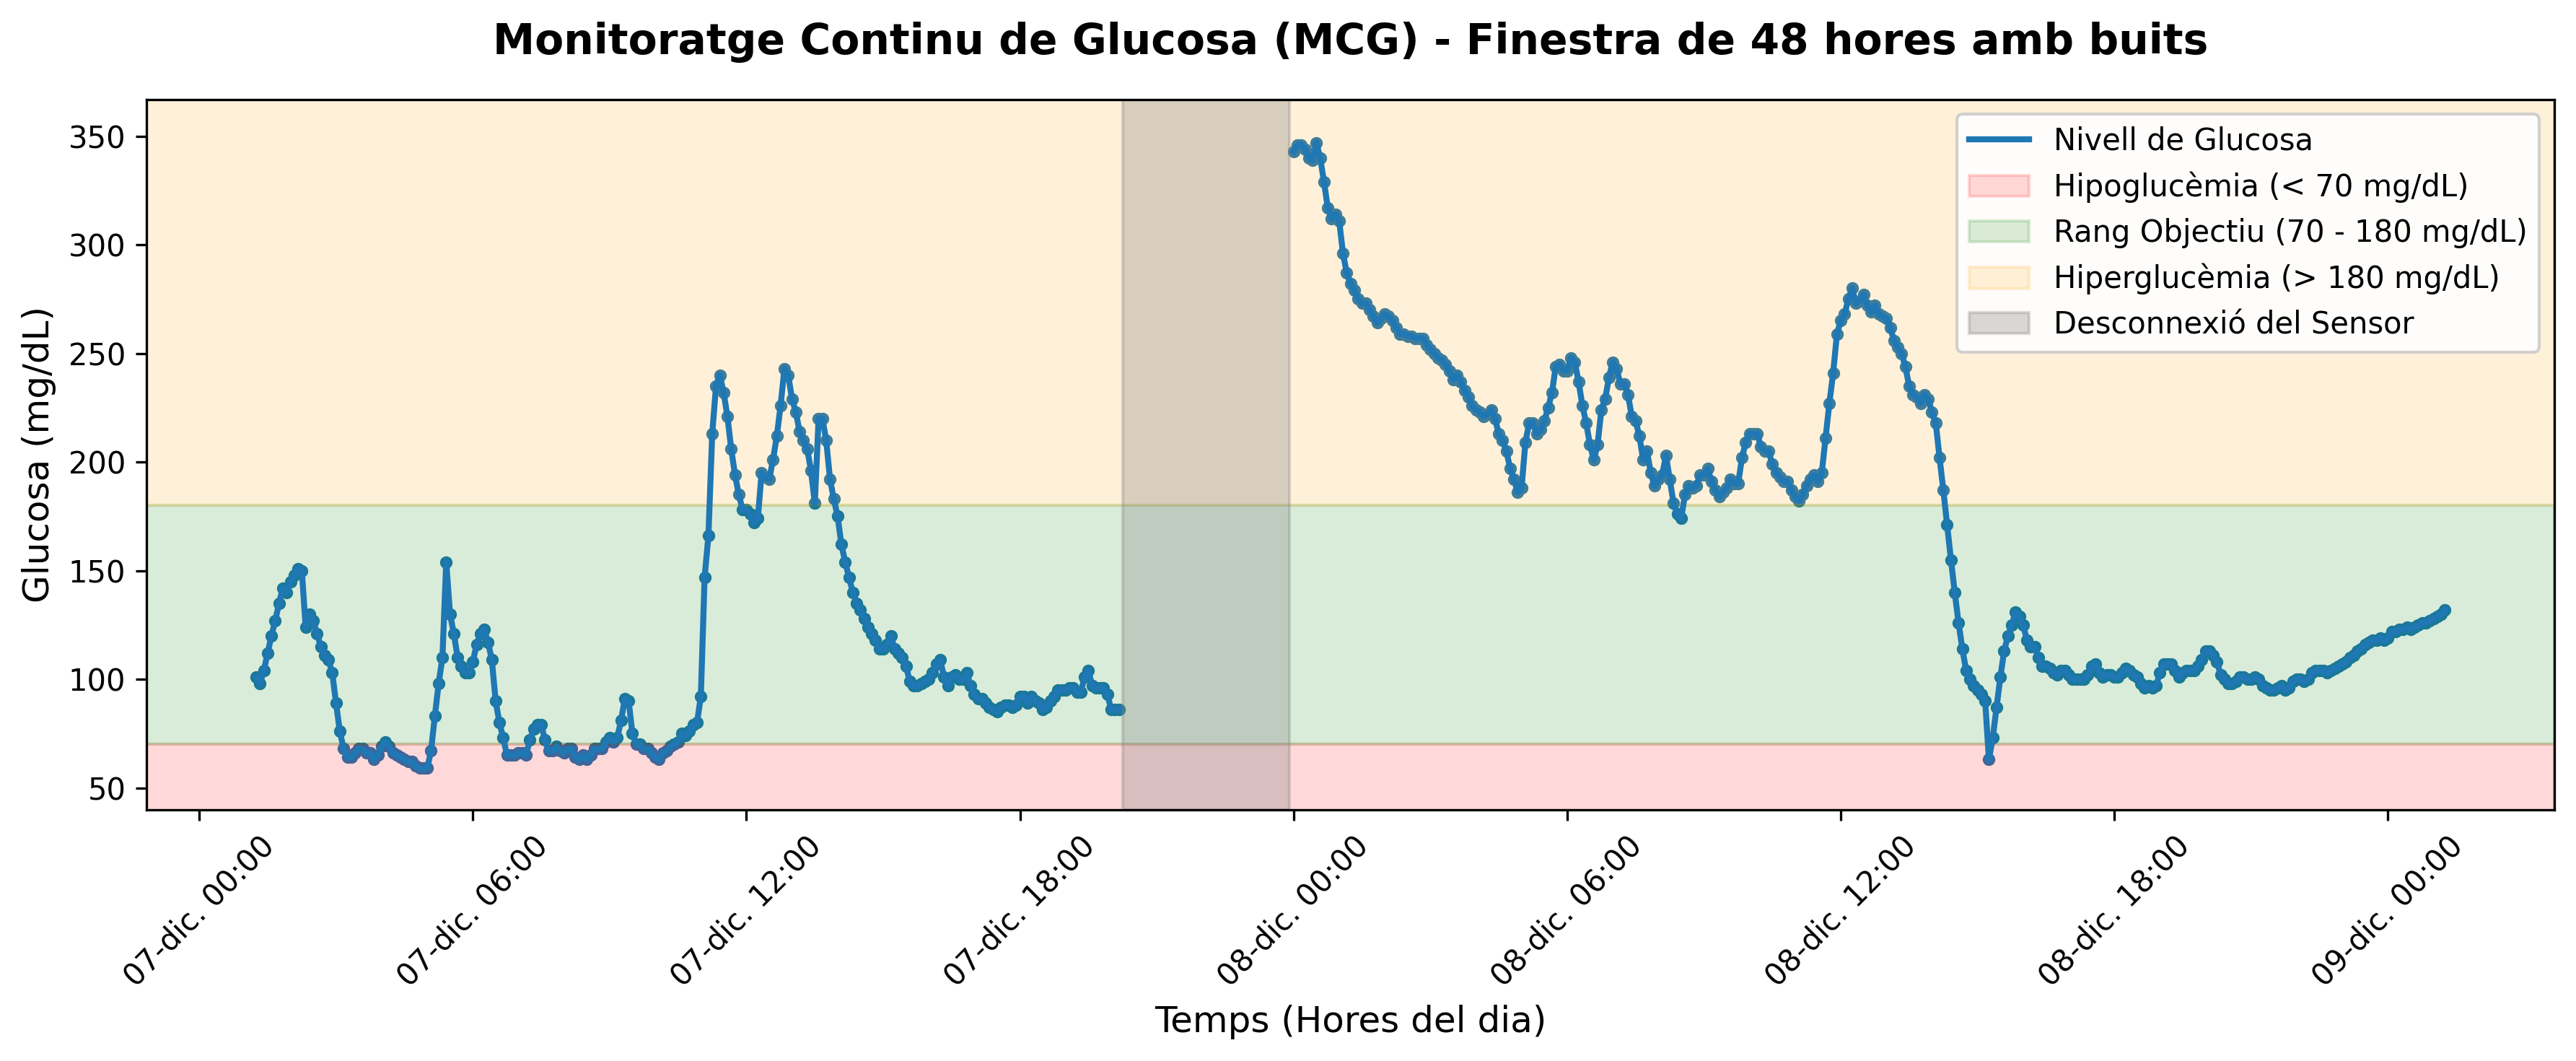

In [22]:
print("Generant la gràfica d'exemple MCG amb buits reals (48 hores)...")

ruta_archivo = "archive/559-ws-training.xml"

# Extracció i quadrícula regular
root = ET.parse(ruta_archivo).getroot()
data = [{"timestamp": ev.get("ts"), "glucose": ev.get("value")} for ev in root.find('glucose_level').findall('event')]
df = pd.DataFrame(data)
df['glucose'] = pd.to_numeric(df['glucose'], errors='coerce')
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)
df = df.set_index('timestamp').sort_index()
df = df[~df.index.duplicated(keep='first')].resample('5min').mean()

# Selecció 48h
data_inici = df.dropna().index[0]
df_segment = df.loc[data_inici:data_inici + pd.Timedelta(hours=48)]

fig, ax = plt.subplots(figsize=(12, 5), dpi=300)
ax.plot(df_segment.index, df_segment['glucose'], color='#1f77b4', linewidth=2, label='Nivell de Glucosa')
ax.scatter(df_segment.index, df_segment['glucose'], color='#1f77b4', s=10)

ax.axhspan(0, 70, color='red', alpha=0.15, label='Hipoglucèmia (< 70 mg/dL)')
ax.axhspan(70, 180, color='green', alpha=0.15, label='Rang Objectiu (70 - 180 mg/dL)')
ax.axhspan(180, 400, color='orange', alpha=0.15, label='Hiperglucèmia (> 180 mg/dL)')

# Detecció visual del buit
mask_nans = df_segment['glucose'].isna()
if mask_nans.any():
    buit_grups = df_segment[mask_nans].groupby(mask_nans.ne(mask_nans.shift()).cumsum())
    if buit_grups.groups:
        buit_mes_llarg = max(buit_grups, key=lambda g: len(g[1]))[1]
        ax.axvspan(buit_mes_llarg.index[0], buit_mes_llarg.index[-1], color='grey', alpha=0.3, label='Desconnexió del Sensor')

ax.set_title("Monitoratge Continu de Glucosa (MCG) - Finestra de 48 hores amb buits", fontsize=14, pad=15, fontweight='bold')
ax.set_ylabel("Glucosa (mg/dL)", fontsize=12)
ax.set_xlabel("Temps (Hores del dia)", fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.xticks(rotation=45)
plt.ylim(40, max(300, df_segment['glucose'].max() + 20))

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper right', fontsize=10, framealpha=0.9)
plt.tight_layout()

ruta_guardat = os.path.join(carpeta_eda, "exemple_cgm_48h_buits.png")
plt.savefig(ruta_guardat, format='png', dpi=300, bbox_inches='tight')
plt.show()

### 4. Distribució de la Longitud dels Segments Continus per Pacient

Una vegada analitzada la presència de buits, és indispensable avaluar la distribució de la durada dels fragments continus resultants abans de procedir a la fase d'entrenament dels models. Atès que l'arquitectura predictiva requereix un historial de dades homogeni i seguint el criteri metodològic establert, es fixa un llindar crític de selecció de 12 hores tant per al conjunt d'entrenament com de prova. A continuació, se representa la dispersió de la durada dels segments detectats per a cada pacient, identificant gràficament aquells fragments que seran admesos (durada $\ge$ 12h) i els que quedaran descartats per no assolir la longitud mínima requerida.

Es calcula la longitud dels segments continus per pacient (Llindar: 12h)...


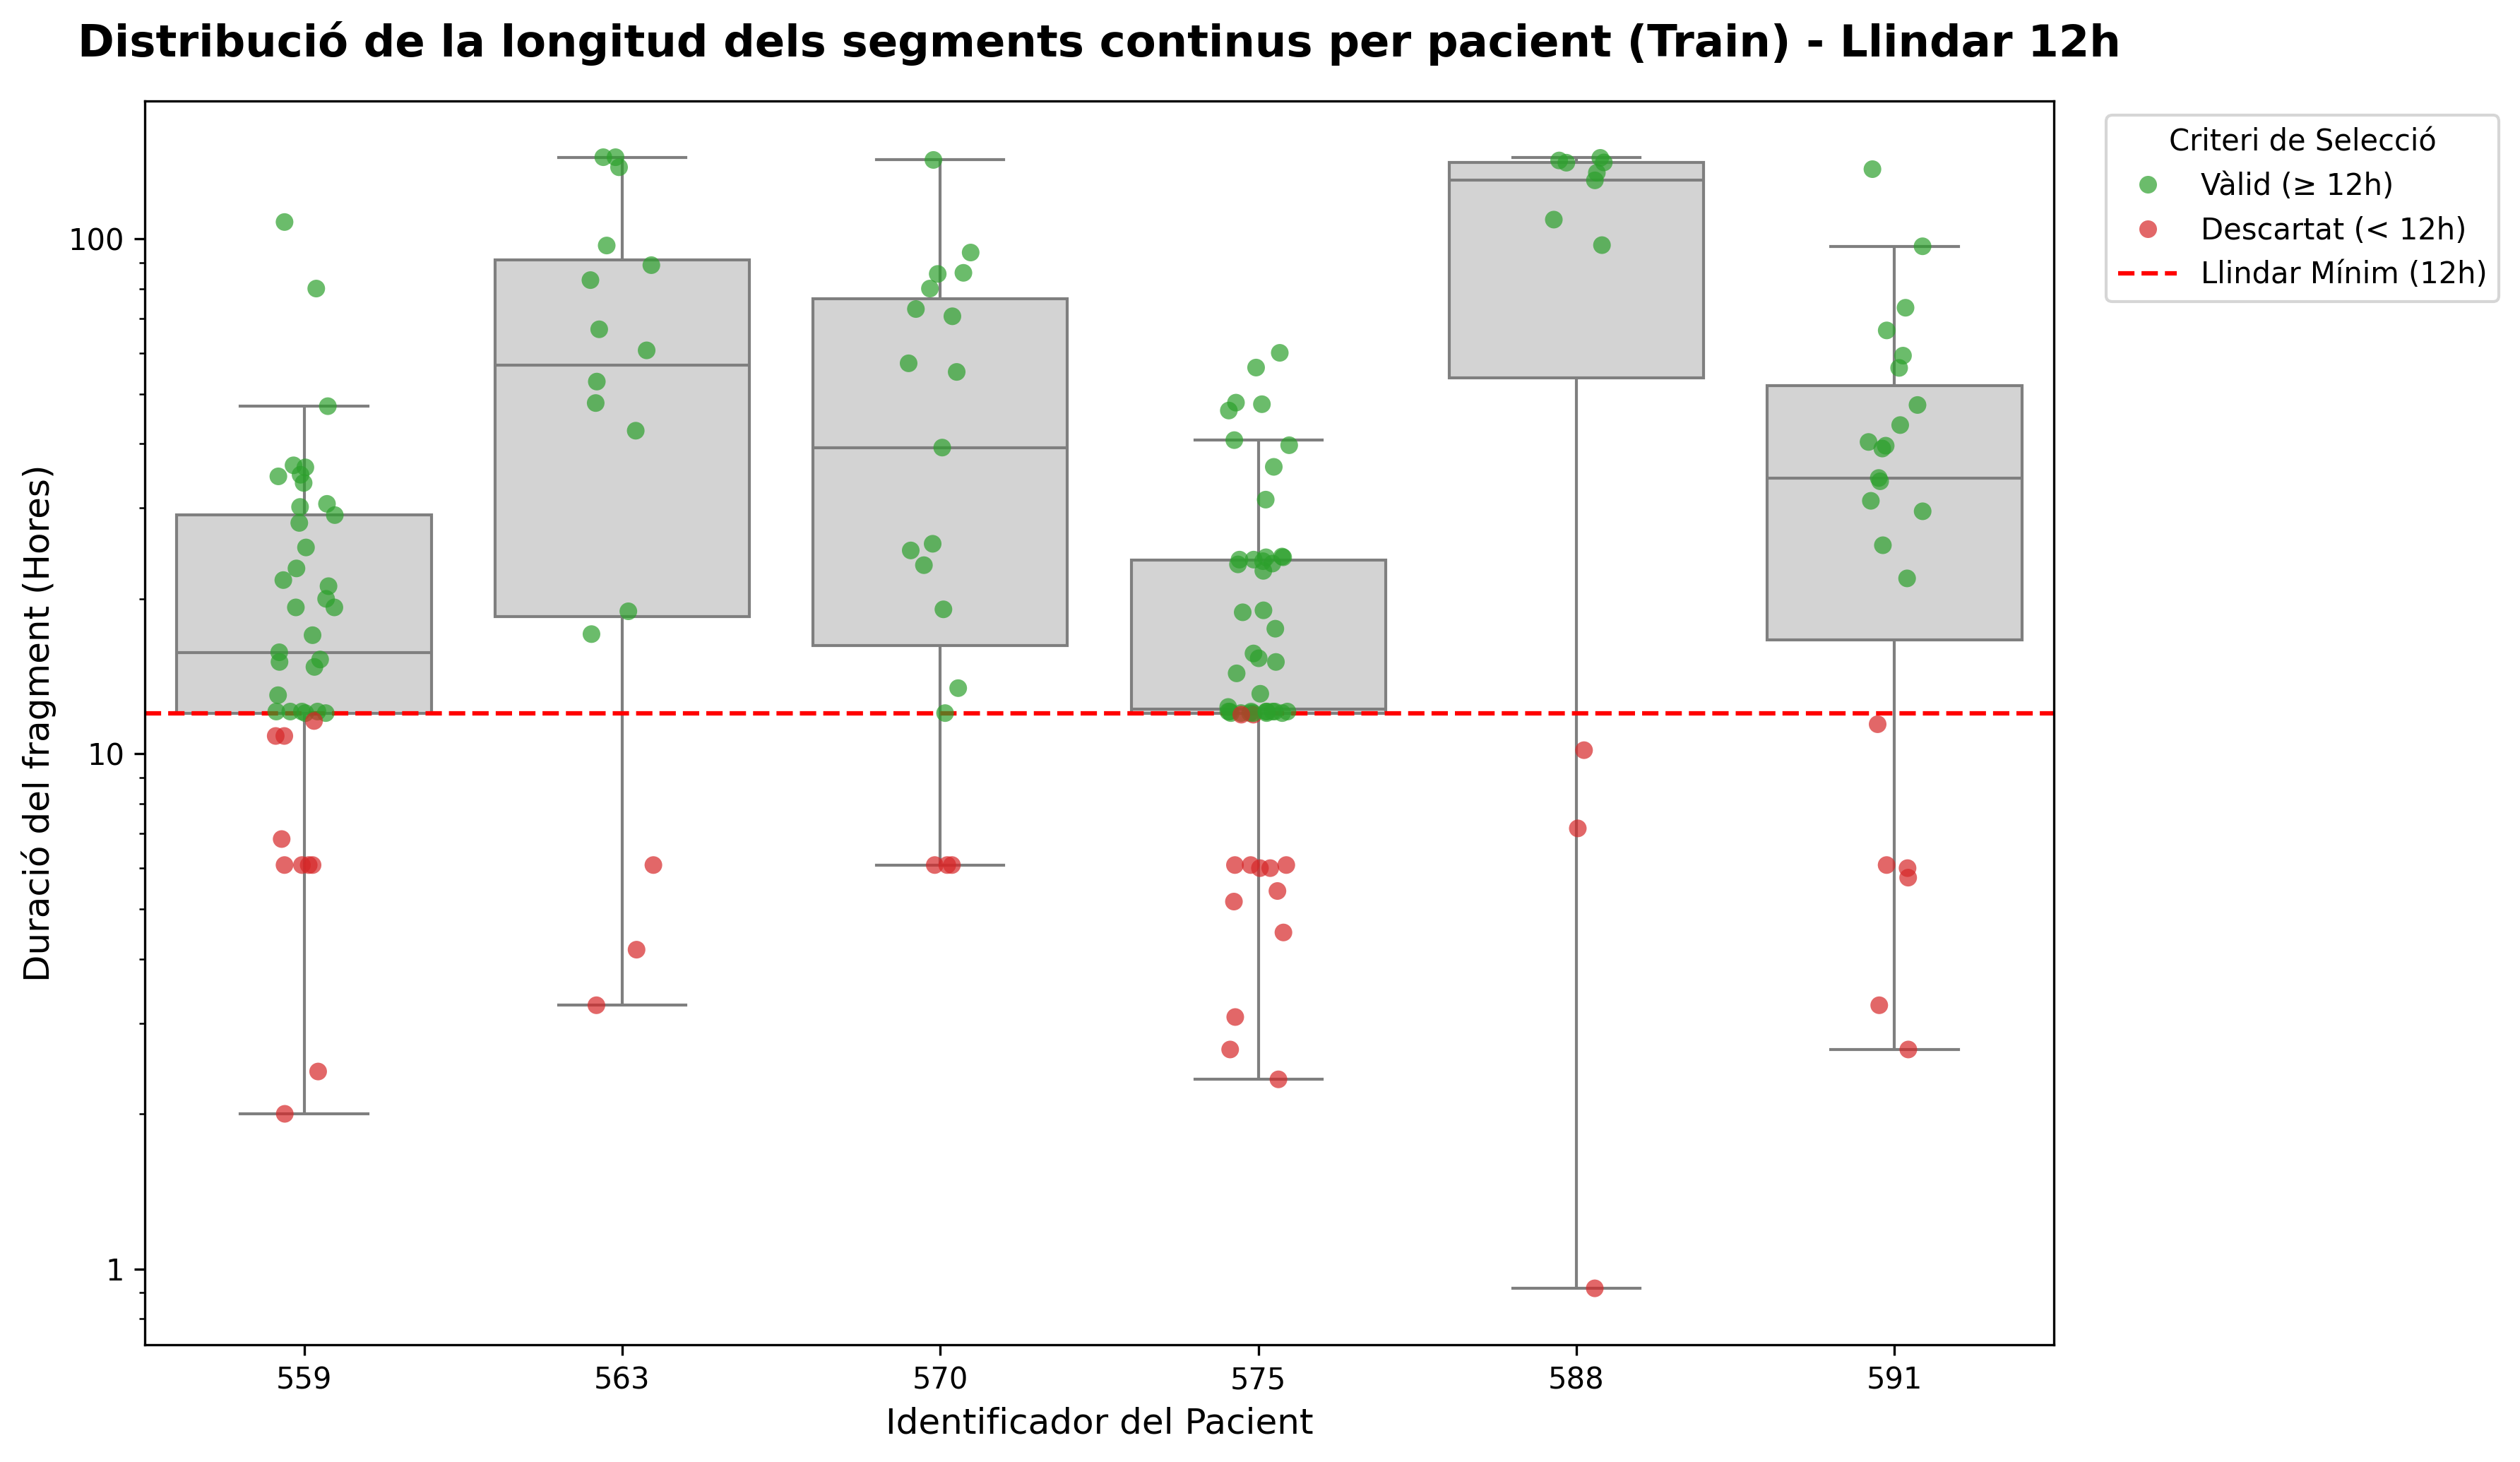

✅ Imatge generada i actualitzada correctament a 'resultats_grafics/analisi_exploratori\distribucio_segments_pacients.png'


In [23]:
print("Es calcula la longitud dels segments continus per pacient (Llindar: 12h)...")

rutas_train = glob.glob("archive/*-ws-training.xml")
dades_segments = []

# Definim els criteris de tall modificats segons el criteri metodològic (12 hores)
hores_minimes = 12
mostres_minimes = hores_minimes * 12 

for ruta in rutas_train:
    pacient_id = os.path.basename(ruta).split('-')[0]
    
    try:
        tree = ET.parse(ruta)
        root = tree.getroot()
        glucose_section = root.find('glucose_level')
        if glucose_section is None: continue

        # Extraic i formate les dades del fitxer XML
        data = [{"timestamp": ev.get("ts"), "glucose": ev.get("value")} for ev in glucose_section.findall('event')]
        df = pd.DataFrame(data)
        df['glucose'] = pd.to_numeric(df['glucose'], errors='coerce')
        df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)
        df = df.set_index('timestamp').sort_index()
        
        # Reformatat regular a 5 minuts i interpolació lineal de petits buits (fins a 15 minuts)
        df_regular = df.resample('5min').mean()
        df_regular['glucose_imputed'] = df_regular['glucose'].interpolate(method='linear', limit=3)
        
        # Identifique els fragments continus post-imputació
        mask_nans = df_regular['glucose_imputed'].isna()
        df_regular['segment_id'] = (mask_nans != mask_nans.shift()).cumsum()
        df_clean = df_regular.dropna(subset=['glucose_imputed'])
        
        # Agrupe i calcule les dimensions de cada fragment
        tamanys = df_clean.groupby('segment_id').size()
        
        for seg_id, quantitat_mostres in tamanys.items():
            duracio_hores = (quantitat_mostres * 5) / 60
            estat = "Vàlid (≥ 12h)" if duracio_hores >= hores_minimes else "Descartat (< 12h)"
            
            dades_segments.append({
                'Pacient': pacient_id,
                'Duració_Hores': duracio_hores,
                'Estat': estat
            })
            
    except Exception as e:
        print(f"Error en processar {ruta}: {e}")

df_segments = pd.DataFrame(dades_segments)

# DIBUIX DE LA GRÀFICA COMBINADA (Boxplot + Stripplot)
plt.figure(figsize=(12, 7), dpi=300)

# Dibuix de la caixa de fons (distribució general sense incloure els valors atípics)
sns.boxplot(
    data=df_segments, 
    x='Pacient', 
    y='Duració_Hores', 
    color='lightgray',
    showfliers=False 
)

# Superposició dels punts individuals mitjançant stripplot per apreciar la densitat amb el nou llindar
sns.stripplot(
    data=df_segments, 
    x='Pacient', 
    y='Duració_Hores', 
    hue='Estat',
    palette={'Vàlid (≥ 12h)': '#2ca02c', 'Descartat (< 12h)': '#d62728'}, 
    jitter=True,
    alpha=0.7,
    size=6
)

# Traçat de la nova línia de tall ajustada a les 12 hores demanades
plt.axhline(y=hores_minimes, color='red', linestyle='--', linewidth=1.5, label='Llindar Mínim (12h)')

# Format dels eixos i títols
plt.title('Distribució de la longitud dels segments continus per pacient (Train) - Llindar 12h', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Identificador del Pacient', fontsize=12)
plt.ylabel('Duració del fragment (Hores)', fontsize=12)

# Escala logarítmica per visualitzar correctament la dispersió
plt.yscale('log') 

# Configuració del format de l'eix Y per evitar la notació científica
ax = plt.gca()
from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter()
formatter.set_scientific(False) 
ax.yaxis.set_major_formatter(formatter)

# Filtratge de llegendes duplicades
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, title='Criteri de Selecció', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.tight_layout()

# Exportació fent servir la ruta global
ruta_guardat_boxplots = os.path.join(carpeta_eda, "distribucio_segments_pacients.png")
plt.savefig(ruta_guardat_boxplots, format='png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Imatge generada i actualitzada correctament a '{ruta_guardat_boxplots}'")

### 5. Propietats Estadístiques: Autocorrelació (ACF i PACF)

Una vegada garantida la qualitat i continuïtat dels segments temporals, l'anàlisi exploratòria se centra en les propietats estadístiques subjacents del senyal glucèmic. L'estudi de la Funció d'Autocorrelació (ACF) i la Funció d'Autocorrelació Parcial (PACF) és un pas fonamental per avaluar la dependència temporal del procés i establir els ordres teòrics dels components autoregressius (AR) i de mitjana mòbil (MA) per al futur modelatge ARIMA. A continuació, es visualitzen les dues funcions sobre un segment net de 48 hores per observar el grau d'inèrcia metabòlica.

Generant les gràfiques ACF i PACF d'exemple...


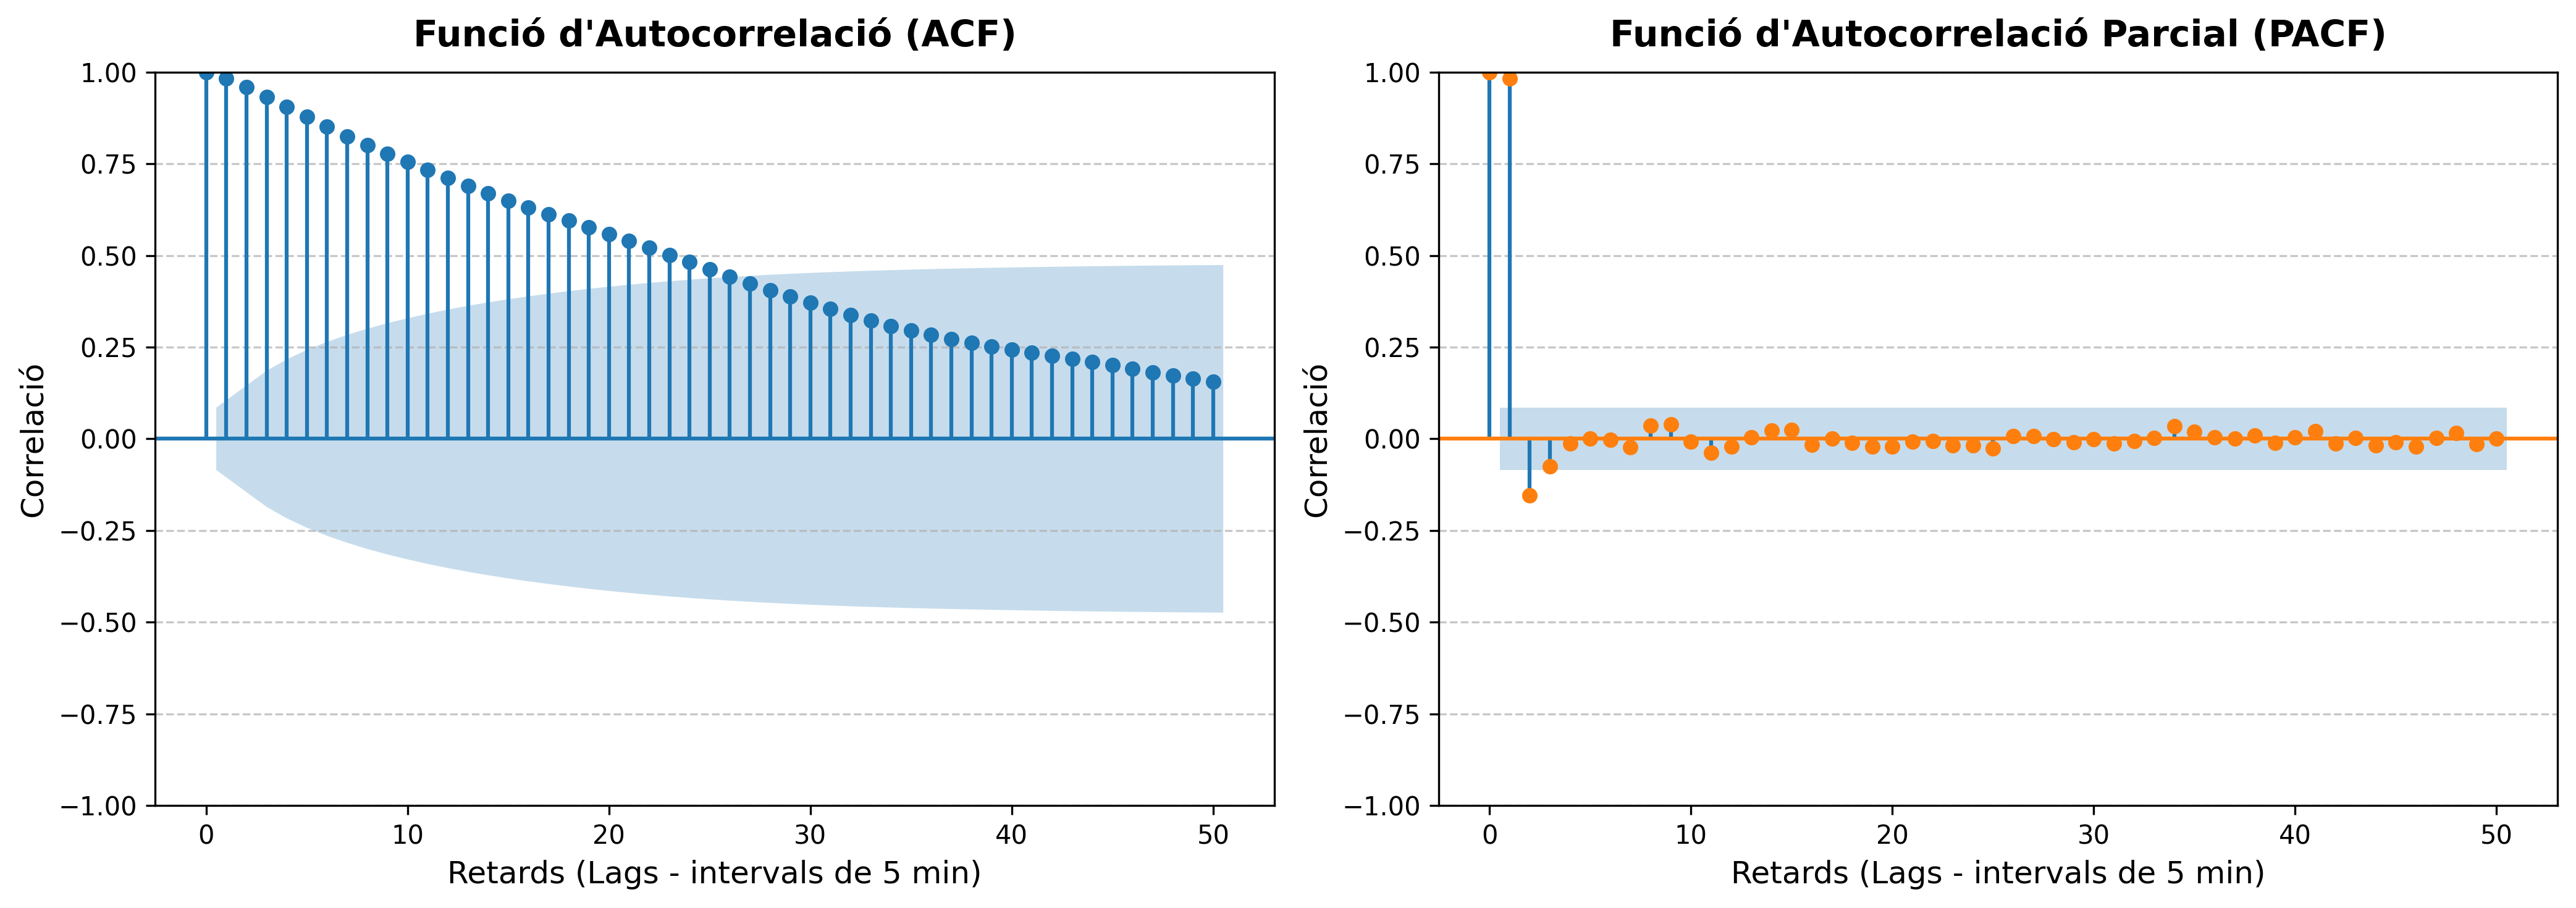

✅ Gràfica generada correctament a 'resultats_grafics/analisi_exploratori\correlacio_acf_pacf.png'


In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("Generant les gràfiques ACF i PACF d'exemple...")

ruta_arxiu = "archive/559-ws-training.xml"

try:
    # 1. Extraic i prepare les dades del pacient d'exemple
    tree = ET.parse(ruta_arxiu)
    root = tree.getroot()
    glucose_section = root.find('glucose_level')
    
    data = [{"timestamp": ev.get("ts"), "glucose": ev.get("value")} for ev in glucose_section.findall('event')]
    df = pd.DataFrame(data)
    df['glucose'] = pd.to_numeric(df['glucose'], errors='coerce')
    df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)
    df = df.set_index('timestamp').sort_index()
    
    # Elimine duplicats i force la quadrícula de 5 minuts
    df = df[~df.index.duplicated(keep='first')]
    df_regular = df.resample('5min').mean()
    df_regular['glucose_imputed'] = df_regular['glucose'].interpolate(method='linear', limit=3)

    # Seleccione un segment continu net de 48 hores per a l'anàlisi estadística
    data_inici = df_regular.dropna().index[0]
    data_fi = data_inici + pd.Timedelta(hours=48)
    df_segment = df_regular.loc[data_inici:data_fi].dropna()

    # 2. Genere la figura doble (ACF i PACF) mantenint l'estil global
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

    # Gràfica ACF
    plot_acf(df_segment['glucose_imputed'], ax=axes[0], lags=50, color='#1f77b4', alpha=0.05)
    axes[0].set_title("Funció d'Autocorrelació (ACF)", fontsize=14, pad=10, fontweight='bold')
    axes[0].set_xlabel("Retards (Lags - intervals de 5 min)", fontsize=12)
    axes[0].set_ylabel("Correlació", fontsize=12)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Gràfica PACF (amb method='ywm' per a evitar warnings de statsmodels)
    plot_pacf(df_segment['glucose_imputed'], ax=axes[1], lags=50, color='#ff7f0e', alpha=0.05, method='ywm')
    axes[1].set_title("Funció d'Autocorrelació Parcial (PACF)", fontsize=14, pad=10, fontweight='bold')
    axes[1].set_xlabel("Retards (Lags - intervals de 5 min)", fontsize=12)
    axes[1].set_ylabel("Correlació", fontsize=12)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    
    # 3. Guarde la figura en la ruta global de l'EDA sense numeració estricta
    ruta_guardat_png = os.path.join(carpeta_eda, "correlacio_acf_pacf.png")
    plt.savefig(ruta_guardat_png, format='png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Gràfica generada correctament a '{ruta_guardat_png}'")
    
except Exception as e:
    print(f"❌ S'ha produït un error en la generació estadísitca: {e}")

### 6. Avaluació de Qualitat: Talls i Buits Màxims (Gaps)

Per concloure l'anàlisi de qualitat del senyal del sensor (MCG), és necessari quantificar la gravetat de les interrupcions detectades prèviament. En aquesta secció s'avalua el conjunt d'entrenament per identificar qualsevol tall de connexió superior a 7 minuts. Es calcula el nombre total d'interrupcions per pacient i, de manera crítica, la durada del buit màxim registrat en hores. Aquesta mètrica permet conèixer el pitjor escenari d'absència de dades al qual hauran d'enfrontar-se els mètodes d'imputació.

In [26]:
import warnings
warnings.filterwarnings("ignore") 

print("Analitzant la qualitat de les dades crues (talls i buits màxims)...")

# Busque tots els arxius XML d'entrenament
llista_arxius = glob.glob("archive/*-ws-training.xml")

resum_qualitat = []

# Itere sobre cada pacient per extraure exclusivament el senyal de glucosa
for ruta_arxiu in llista_arxius:
    nom_arxiu = os.path.basename(ruta_arxiu)
    pacient_id = nom_arxiu.split('-')[0]
    
    try:
        tree = ET.parse(ruta_arxiu)
        root = tree.getroot()
        
        glucose_section = root.find('glucose_level')
        if glucose_section is None: continue
            
        data_glucose = [{"timestamp": ev.get("ts"), "glucose": ev.get("value")} for ev in glucose_section.findall('event')]
        df_g = pd.DataFrame(data_glucose)
        
        # Formate les dades de glucosa
        df_g['glucose'] = pd.to_numeric(df_g['glucose'], errors='coerce')
        df_g['timestamp'] = pd.to_datetime(df_g['timestamp'], dayfirst=True)
        df_g = df_g.set_index('timestamp').dropna().sort_index()
        
        # Detecte els talls de connexió (diferència de temps > 7 minuts entre registres)
        diff_min = df_g.index.to_series().diff().dt.total_seconds() / 60
        buits = diff_min[diff_min > 7]
        max_buit = buits.max() if not buits.empty else 0
        
        # Guarde les estadístiques a la llista resum
        resum_qualitat.append({
            'Pacient': pacient_id,
            'Num_Talls': len(buits),
            'Max_Buit_Hores': round(max_buit / 60, 2)
        })
        
    except Exception as e:
        print(f"❌ S'ha produït un error en processar el pacient {pacient_id}: {e}")

# Cree el DataFrame, l'ordene pel buit més greu i el mostre
df_resum = pd.DataFrame(resum_qualitat).sort_values('Max_Buit_Hores', ascending=False)
print("\n--- RESUM DE QUALITAT DEL SENYAL (TRAIN) ---")
display(df_resum)

# Exportació fent servir la ruta global de l'EDA
ruta_taula_resum = os.path.join(carpeta_eda, "resum_qualitat_talls_maxims.csv")
df_resum.to_csv(ruta_taula_resum, index=False)
print(f"✅ Taula exportada correctament a '{ruta_taula_resum}'")

Analitzant la qualitat de les dades crues (talls i buits màxims)...

--- RESUM DE QUALITAT DEL SENYAL (TRAIN) ---


,Pacient,Num_Talls,Max_Buit_Hores
5,591,26,80.63
1,563,21,24.10
0,559,42,13.05
4,588,10,12.62
2,570,20,12.12
3,575,72,11.40


✅ Taula exportada correctament a 'resultats_grafics/analisi_exploratori\resum_qualitat_talls_maxims.csv'
